<a href="https://colab.research.google.com/github/NEFAxRAJ/Machine-Learning-Practices/blob/main/Decision_tree_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####**B.3. Write Python code to implement the ID3 algorithm and test it on the PlayTennis dataset, verifying the inductive bias of the decision tree learning algorithm.**

####**ID3 (Iterative Dichotomiser 3) is a top-down, greedy algorithm for building decision trees. At each node, it selects the attribute with maximum information gain and recursively splits until stopping conditions are met.**

$\text{Entropy}(S) = - \sum_{i=1}^{n} p_i \log_2(p_i)$

Where:

*   $p_i$ = probability of class i
*   n = number of distinct class labes

####**Information Gain**-Information Gain measures the reduction in entropy after splitting on attribute \(A\):

${Gain}(S, A) = \text{Entropy}(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} \text{Entropy}(S_v)$

where $S_v = subset of S with attribute A = v, |S_v| = number of instances in S_v, |S| = total instances in (S).$

####**Attribute Selection**
At each node, choose the attribute $(A^*) with maximum information gain:$

$
A^* = \arg\max_{A} \text{Gain}(S, A)
$

####**Stopping Conditions**
Stop splitting if:  

$
\text{Entropy}(S) = 0 \quad \text{or no attributes left to split.}
$

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/play_tennis.csv')

In [ ]:
df.head()

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [ ]:
import math
from collections import Counter


$
\text{Entropy}(S) = - \sum_{i=1}^{n} p_i \log_2(p_i)$

Where:

*   $p_i$ = probability of class i
*   n = number of distinct class labels

Entropy Measures impurity or uncertainity in a dataset.





In [ ]:
def entropy(data):
    labels = [row[-1] for row in data]
    label_counts = Counter(labels)

    ent = 0
    for count in label_counts.values():
        p = count / len(labels)
        ent -= p * math.log2(p)
    return ent


$
\text{IG}(S, A) = \text{Entropy}(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} \, \text{Entropy}(S_v)
$

S = entire dataset

A = attribute(feature) used to split

Sᵥ = subset of S for which attribute A has value v

|S| = total number of instances in S

|Sᵥ| = number of instances in subset Sᵥ

Information Gain measures how much uncertainty is reduced in the dataset after splitting on attribute A.

ID3 selects the attribute with maximum information gain as the split node

In [ ]:
def information_gain(data, feature_index):

    #Entropy of full dataset
    total_entropy = entropy(data)

    #Getting unique value of feature
    feature_values = set(row[feature_index] for row in data)
    weighted_entropy = 0

    #Entropy of each subset
    for value in feature_values:
        subset = [row for row in data if row[feature_index] == value]
        weighted_entropy += (len(subset) / len(data)) * entropy(subset)

    return total_entropy - weighted_entropy


The feature with:

max
⁡
(
Gain
(
𝑆
,
𝐴
)
)


is selected.

In [ ]:
def best_feature(data):
    gains = []
    for i in range(len(data[0]) - 1):  # excluding label
        gains.append(information_gain(data, i))
    return gains.index(max(gains))


At each node, ID3 selects the attribute:

$
A^* = \arg\max_{A} \; \text{Gain}(S, A)$

With stopping conditions:

*  $\text{Entropy}(S) = 0$
*  No attributes left


In [ ]:
def id3(data, features):
    labels = [row[-1] for row in data]

    # Case 1: all labels same
    if len(set(labels)) == 1:
        return labels[0]

    # Case 2: no features left
    if len(features) == 0:
        return Counter(labels).most_common(1)[0][0]

    # Select the best feature using Information Gain
    best_feat_index = best_feature(data)
    best_feat_name = features[best_feat_index]

    # Create the decision tree node
    tree = {best_feat_name: {}}

    # Get all unique values of the best feature
    feature_values = set(row[best_feat_index] for row in data)

    # # Create subtrees for each feature value
    for value in feature_values:
        subset = [
            row[:best_feat_index] + row[best_feat_index + 1:]
            for row in data if row[best_feat_index] == value
        ]

        remaining_features = features[:best_feat_index] + features[best_feat_index + 1:]
        tree[best_feat_name][value] = id3(subset, remaining_features)

    return tree


In [ ]:
data=df.drop(columns='day', axis=1)
features=data.columns.tolist()
data=data.to_numpy().tolist()

In [ ]:
data
#features

[['Sunny', 'Hot', 'High', 'Weak', 'No'],
 ['Sunny', 'Hot', 'High', 'Strong', 'No'],
 ['Overcast', 'Hot', 'High', 'Weak', 'Yes'],
 ['Rain', 'Mild', 'High', 'Weak', 'Yes'],
 ['Rain', 'Cool', 'Normal', 'Weak', 'Yes'],
 ['Rain', 'Cool', 'Normal', 'Strong', 'No'],
 ['Overcast', 'Cool', 'Normal', 'Strong', 'Yes'],
 ['Sunny', 'Mild', 'High', 'Weak', 'No'],
 ['Sunny', 'Cool', 'Normal', 'Weak', 'Yes'],
 ['Rain', 'Mild', 'Normal', 'Weak', 'Yes'],
 ['Sunny', 'Mild', 'Normal', 'Strong', 'Yes'],
 ['Overcast', 'Mild', 'High', 'Strong', 'Yes'],
 ['Overcast', 'Hot', 'Normal', 'Weak', 'Yes'],
 ['Rain', 'Mild', 'High', 'Strong', 'No']]

In [ ]:
decision_tree = id3(data, features)
print(decision_tree)


{'outlook': {'Rain': {'wind': {'Strong': 'No', 'Weak': 'Yes'}}, 'Overcast': 'Yes', 'Sunny': {'humidity': {'Normal': 'Yes', 'High': 'No'}}}}


In [ ]:
def predict(tree, instance, features):
    # If the tree is a leaf node, return the class label
    if not isinstance(tree, dict):
        return tree

    # Get the root feature of the tree
    root_feature = next(iter(tree))
    feature_index = features.index(root_feature)

    # Get the value of the feature from the test instance
    feature_value = instance[feature_index]

    # Traverse the subtree corresponding to the feature value
    subtree = tree[root_feature].get(feature_value)

    # If feature value not seen during training
    if subtree is None:
        return None

    # Remove the used feature and recurse
    reduced_instance = (
        instance[:feature_index] + instance[feature_index + 1:]
    )
    reduced_features = (
        features[:feature_index] + features[feature_index + 1:]
    )

    return predict(subtree, reduced_instance, reduced_features)


In [ ]:
test_instance = ['Sunny', 'Cool', 'High', 'Strong']
print("Prediction:", predict(decision_tree, test_instance, features))


Prediction: No


####Validating on the training dataset

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
y_pred=[predict(decision_tree, i, features) for i in data]

In [ ]:
y_true=df['play']

In [ ]:
# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=['Yes','No'])
print("Confusion Matrix:")
print(cm)

# Classification Report
report = classification_report(y_true, y_pred, target_names=['Yes','No'])
print("\nClassification Report:")
print(report)


Accuracy: 100.00%

Confusion Matrix:
[[9 0]
 [0 5]]

Classification Report:
              precision    recall  f1-score   support

         Yes       1.00      1.00      1.00         5
          No       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



####**Creating a decsion tree using Scikit learn to graphically represent the Decision Tree**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Copy original dataframe
df_encoded = df.copy()

# Apply LabelEncoder to all columns
encoders = {}
for column in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    encoders[column] = le  # Save encoder to decode later if needed


In [ ]:

X = df_encoded.drop(columns=['play','day'])
y = df_encoded['play']


In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(
    criterion="entropy",  # same as ID3
    max_depth=3
)

clf.fit(X, y)


DecisionTreeClassifier(criterion='entropy', max_depth=3)

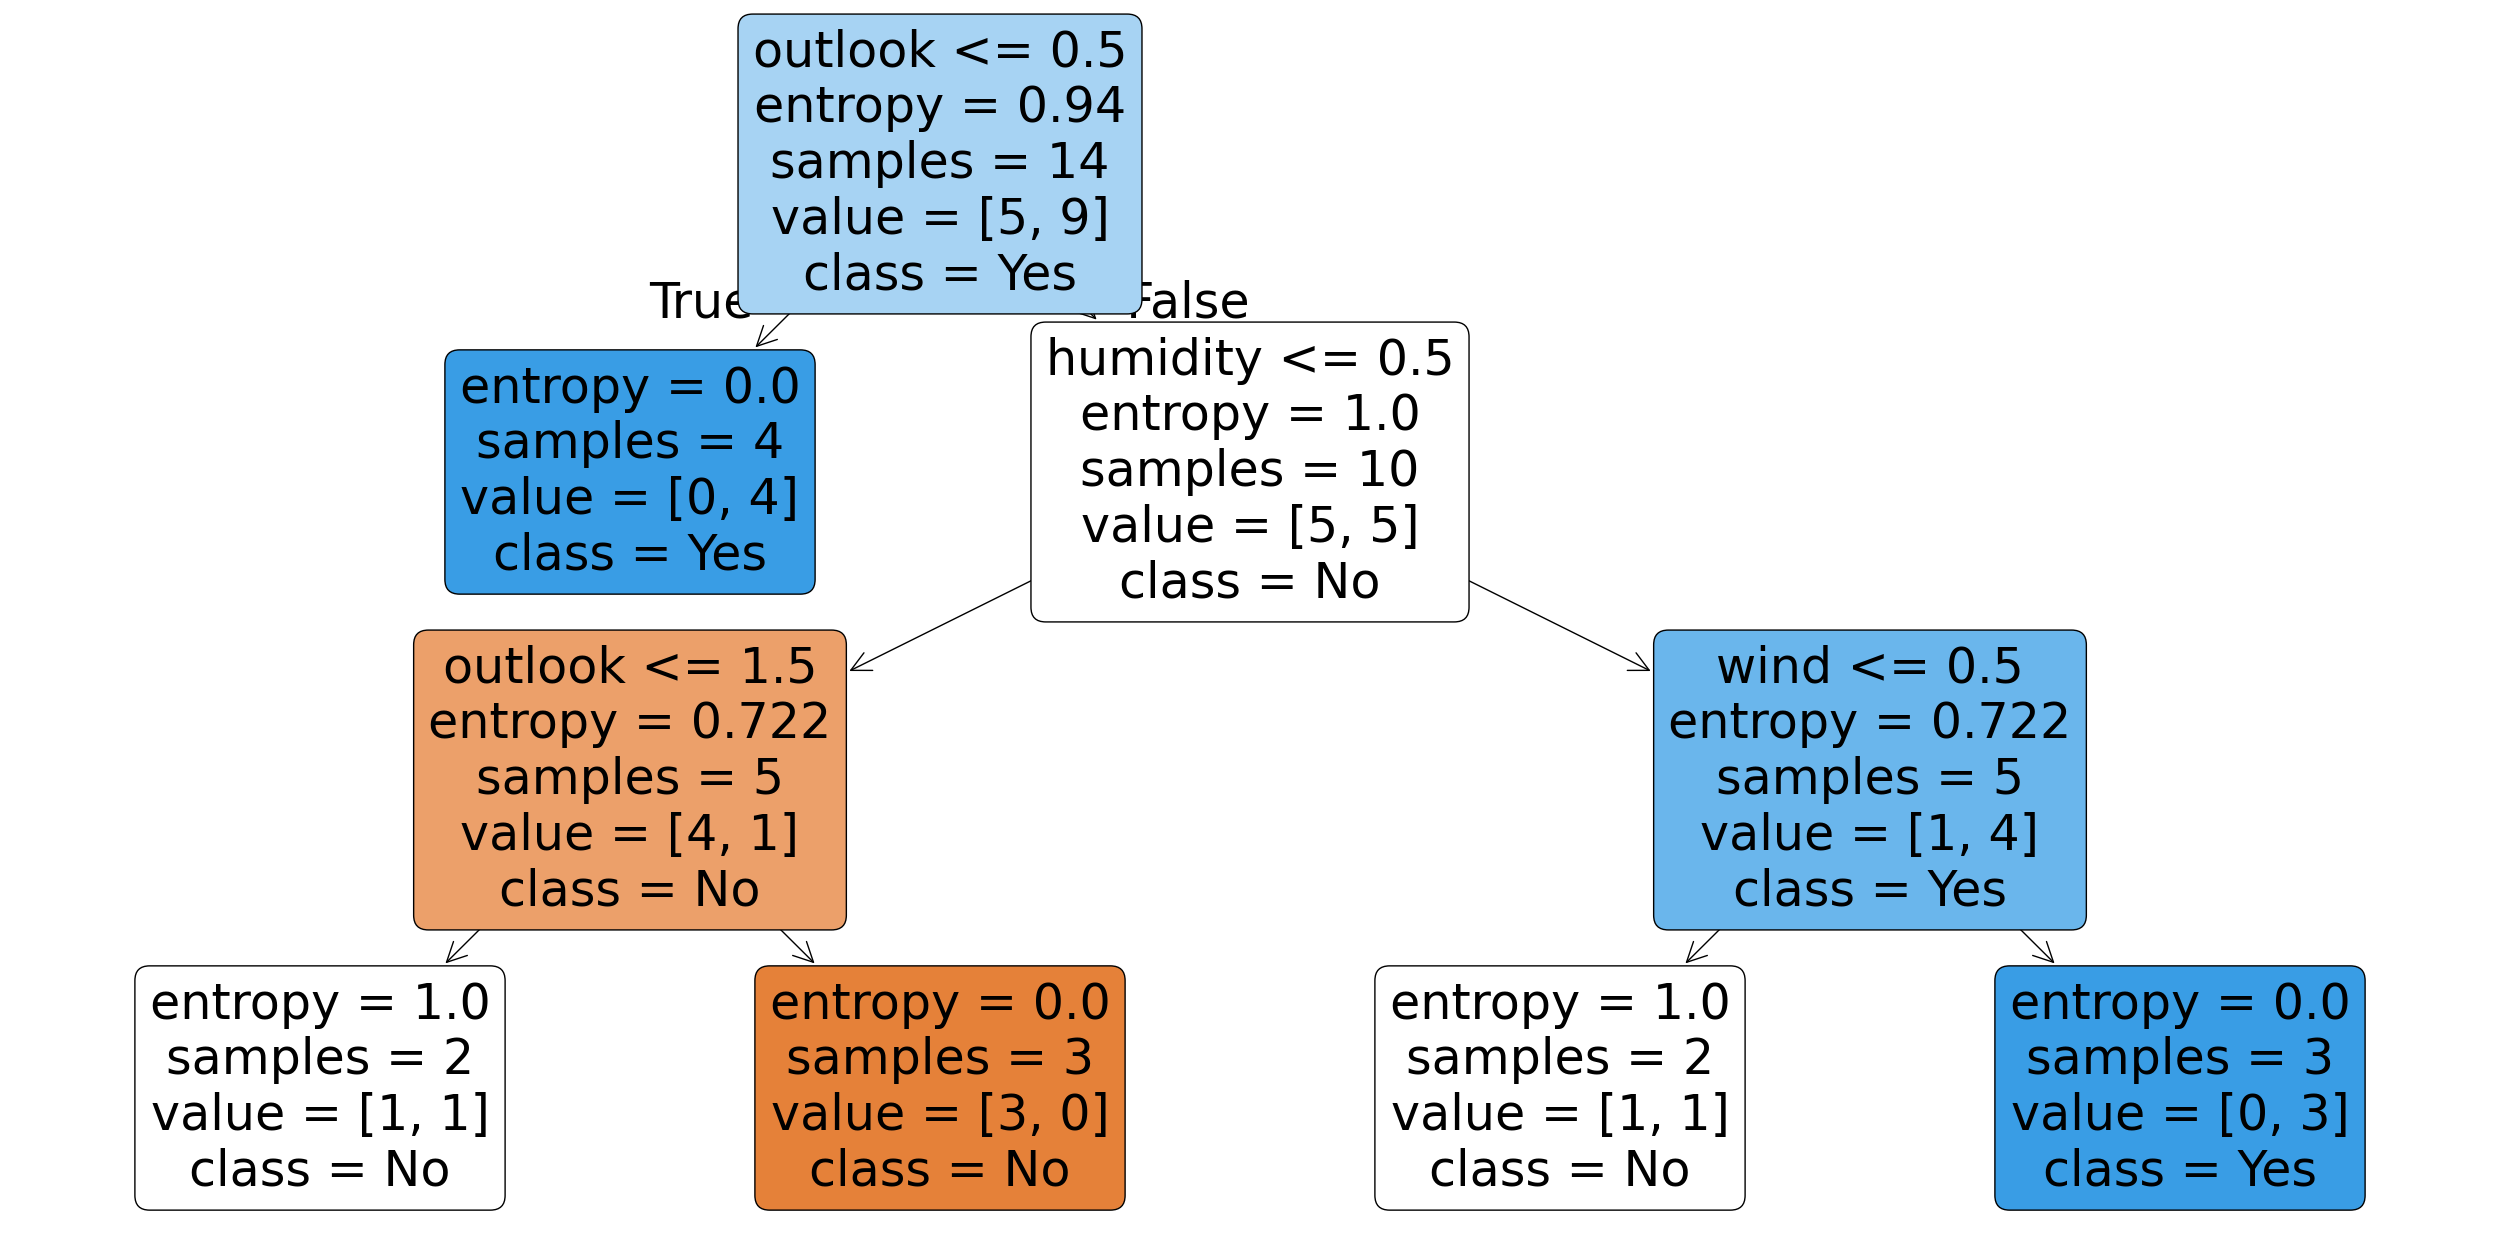

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(32,16 ))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)
plt.show()
